# Breast Cancer Classification — SLP → MLP → Regularization
Wisconsin Diagnostic dataset · TensorFlow/Keras · SLP, MLP, activation functions, early stopping, dropout, L1/L2 regularization.

## 0. Setup
Installs TensorFlow if it isn't already available, then imports everything used below.

In [8]:
%pip install -q tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

RED, CHARCOAL = '#CC0000', '#2C2C2C'

print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


## 1. Data Loading, EDA & Preprocessing
Load `wdbc.data`, check class balance and feature correlation, then split and scale.

In [10]:
base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave points', 'symmetry', 'fractal_dimension']
feature_names = [f'{f}_{s}' for s in ('mean', 'se', 'worst') for f in base_features]
columns = ['id', 'diagnosis'] + feature_names

raw = pd.read_csv('wdbc.data', header=None, names=columns)
X = raw[feature_names].copy()
y = raw['diagnosis'].map({'M': 0, 'B': 1}).rename('target')  # 0 = Malignant, 1 = Benign

print('X shape:', X.shape)
print(y.value_counts())

X shape: (569, 30)
target
1    357
0    212
Name: count, dtype: int64


**Class balance:** 212 Malignant (37%) vs 357 Benign (63%) — a mild imbalance. A stratified split plus precision/recall/F1 tracking is enough here; no SMOTE or class-weighting needed.

In [11]:
import os

os.makedirs('plots', exist_ok=True)

plt.savefig('plots/01_class_distribution.png', dpi=120)
plt.show()

<Figure size 640x480 with 0 Axes>

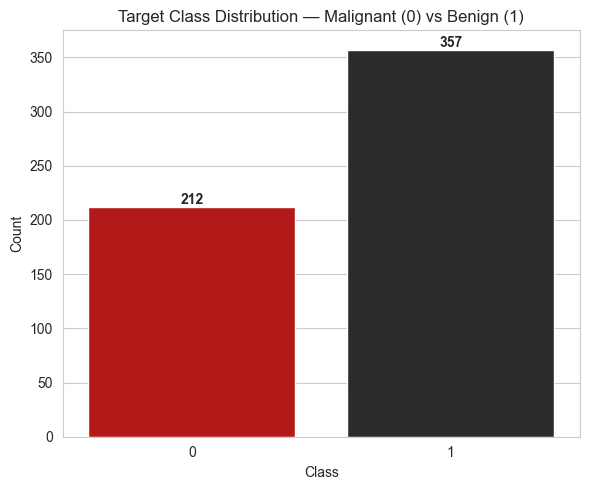

In [12]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=y, hue=y, palette=[RED, CHARCOAL], legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title('Target Class Distribution — Malignant (0) vs Benign (1)')
plt.xlabel('Class'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', dpi=120)
plt.show()

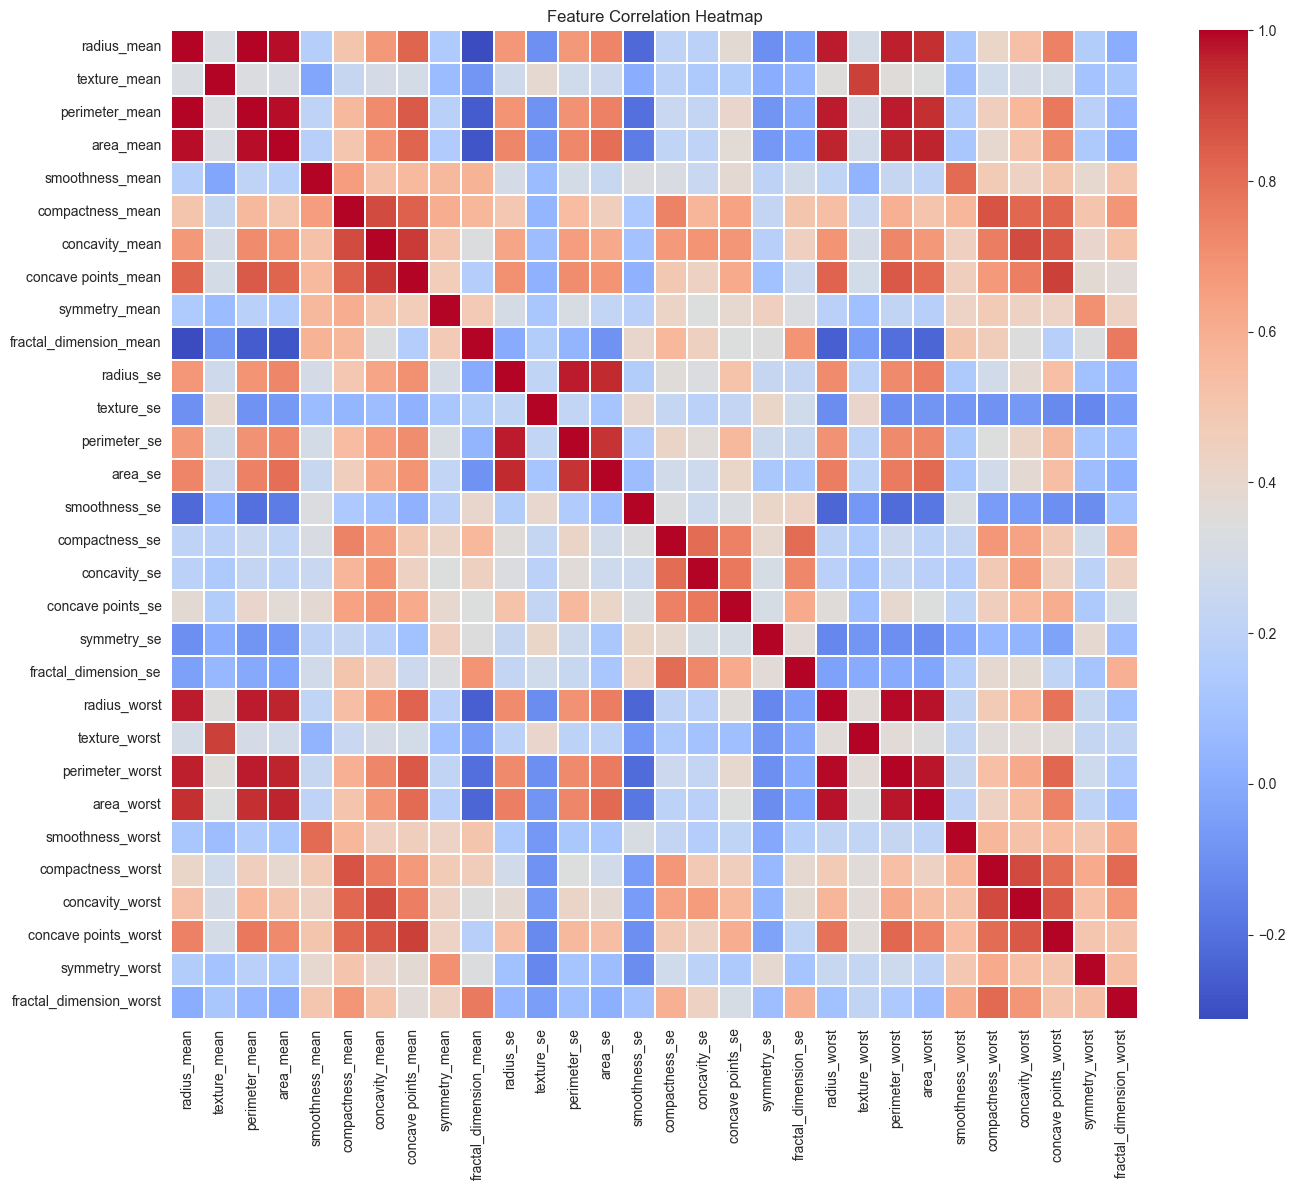

perimeter_mean  radius_mean        0.997855
radius_worst    perimeter_worst    0.993708
radius_mean     area_mean          0.987357
area_mean       perimeter_mean     0.986507
area_worst      radius_worst       0.984015
dtype: float64


In [13]:
corr = X.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/02_correlation_heatmap.png', dpi=120)
plt.show()

pairs = corr.abs().unstack().sort_values(ascending=False)
print(pairs[pairs < 1.0].drop_duplicates().head(5))

**Highly correlated pairs:** `radius`/`perimeter`/`area` (mean & worst) and `concavity`/`concave points` — all describe nucleus size or shape geometrically.

**Why it's fine for neural nets:** unlike linear regression, NNs don't invert a covariance matrix or rely on unique per-feature coefficients — correlated inputs are just extra (redundant) dimensions for gradient descent, costing a few parameters but not stability.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print(y_train.value_counts(normalize=True).round(3).to_dict())
print(y_test.value_counts(normalize=True).round(3).to_dict())

Train: (455, 30) | Test: (114, 30)
{1: 0.626, 0: 0.374}
{1: 0.632, 0: 0.368}


In [15]:
scaler = StandardScaler().fit(X_train)  # fit on train only — never on test
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Scaled train mean ~0:', X_train_sc.mean().round(3))
print('Scaled train std  ~1:', X_train_sc.std().round(3))

Scaled train mean ~0: 0.0
Scaled train std  ~1: 1.0


**Why scale:** features span very different ranges (`area_mean` ~2500 vs `fractal_dimension_mean` ~0.05–0.10). Unscaled, gradients from large-scale features dominate early training and the loss surface becomes elongated, slowing/destabilizing convergence. `StandardScaler` (mean 0, std 1) puts every feature on equal footing.

**Why fit only on `X_train`:** fitting on test data lets test-set statistics leak into preprocessing (data leakage), giving an overly optimistic evaluation.

## 2. Single-Layer Perceptron (SLP) — Baseline
One neuron, sigmoid activation — equivalent to logistic regression. Establishes a linear baseline.

In [16]:
model_slp = keras.Sequential([keras.layers.Dense(1, activation='sigmoid', input_shape=(30,))])
model_slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_slp.summary()  # 31 params = 30 weights + 1 bias

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

**Why `binary_crossentropy`:** it penalizes confident-and-wrong predictions much more than MSE does, and its gradient with a sigmoid output stays well-behaved — the right loss for probabilistic binary classification.

In [17]:
history_slp = model_slp.fit(X_train_sc, y_train, epochs=50, batch_size=32,
                             validation_split=0.1, verbose=1)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6235 - loss: 0.7290 - val_accuracy: 0.5435 - val_loss: 0.7747
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6650 - loss: 0.6709 - val_accuracy: 0.6087 - val_loss: 0.7160
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6944 - loss: 0.6199 - val_accuracy: 0.6304 - val_loss: 0.6638
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7286 - loss: 0.5751 - val_accuracy: 0.6522 - val_loss: 0.6176
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7482 - loss: 0.5357 - val_accuracy: 0.6739 - val_loss: 0.5765
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7702 - loss: 0.5011 - val_accuracy: 0.6957 - val_loss: 0.5399
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7971 - loss: 0.4704 - val_accuracy: 0.6957 - val_loss: 0.5072
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8117 - loss: 0.4431 - val_accuracy: 0.6957 - val_loss

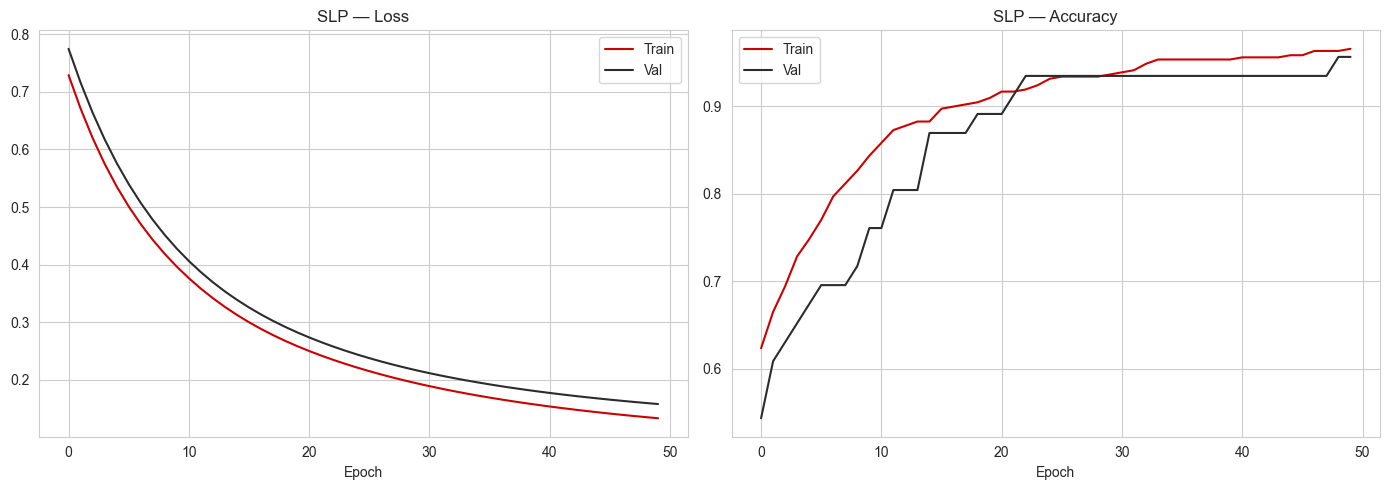

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_slp.history['loss'], color=RED, label='Train')
axes[0].plot(history_slp.history['val_loss'], color=CHARCOAL, label='Val')
axes[0].set_title('SLP — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_slp.history['accuracy'], color=RED, label='Train')
axes[1].plot(history_slp.history['val_accuracy'], color=CHARCOAL, label='Val')
axes[1].set_title('SLP — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('plots/03_slp_training_curves.png', dpi=120)
plt.show()

With only 31 parameters the SLP can't overfit — train/val curves stay close, converging quickly to a modest plateau.

Test Accuracy: 0.9211
              precision    recall  f1-score   support

   Malignant       0.87      0.93      0.90        42
      Benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



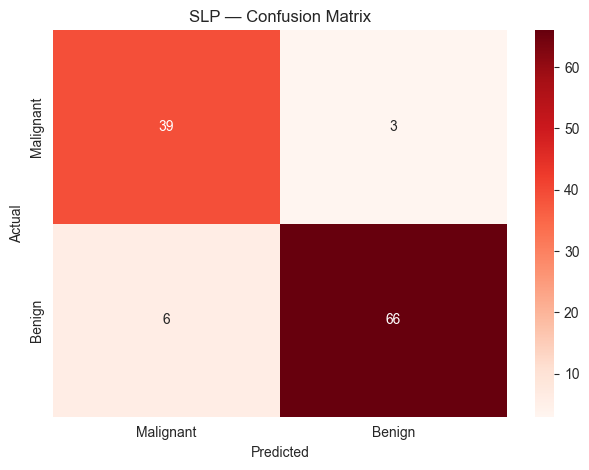

Precision=0.9565  Recall=0.9167  F1=0.9362


In [19]:
slp_loss, slp_acc = model_slp.evaluate(X_test_sc, y_test, verbose=0)
y_pred_slp = (model_slp.predict(X_test_sc, verbose=0) > 0.5).astype(int)

print(f'Test Accuracy: {slp_acc:.4f}')
print(classification_report(y_test, y_pred_slp, target_names=['Malignant', 'Benign']))

sns.heatmap(confusion_matrix(y_test, y_pred_slp), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('SLP — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/04_slp_confusion_matrix.png', dpi=120)
plt.show()

slp_precision = precision_score(y_test, y_pred_slp)
slp_recall = recall_score(y_test, y_pred_slp)
slp_f1 = f1_score(y_test, y_pred_slp)
print(f'Precision={slp_precision:.4f}  Recall={slp_recall:.4f}  F1={slp_f1:.4f}')

**SLP limitation:** a single sigmoid neuron can only draw one hyperplane through the 30-dimensional feature space. Real biological data is rarely linearly separable, so accuracy hits a hard ceiling — motivating hidden layers (Task 3).

## 3. Multi-Layer Perceptron (MLP) — Activation Functions
64→32→1 network. Compares ReLU, Tanh, and Sigmoid in the hidden layers.

In [20]:
model_mlp = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_mlp.summary()

manual_total = (30 * 64 + 64) + (64 * 32 + 32) + (32 * 1 + 1)
assert manual_total == model_mlp.count_params()
print('Manual parameter count matches:', manual_total)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Manual parameter count matches: 4097


**Why hidden layers:** each `Dense` + activation composes a non-linear transform, letting the network build curved decision boundaries the SLP cannot. Two moderate layers (64→32) capture feature interactions without excessive parameters.

In [21]:
model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp = model_mlp.fit(X_train_sc, y_train, epochs=100, batch_size=32,
                             validation_split=0.1, verbose=1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7335 - loss: 0.5432 - val_accuracy: 0.9130 - val_loss: 0.3745
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9560 - loss: 0.3177 - val_accuracy: 0.9565 - val_loss: 0.2567
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9658 - loss: 0.2002 - val_accuracy: 0.9565 - val_loss: 0.1911
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9658 - loss: 0.1381 - val_accuracy: 0.9565 - val_loss: 0.1599
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9633 - loss: 0.1080 - val_accuracy: 0.9565 - val_loss: 0.1416
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9731 - loss: 0.0913 - val_accuracy: 0.9565 - val_loss: 0.1264
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.0802 - val_accuracy: 0.9565 - val_loss: 0.1129
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9829 - loss: 0.0725 - val_accuracy: 0.9565 - 

In [22]:
def build_mlp(activation):
    m = keras.Sequential([
        keras.layers.Dense(64, activation=activation, input_shape=(30,)),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_mlp_tanh = build_mlp('tanh')
history_mlp_tanh = model_mlp_tanh.fit(X_train_sc, y_train, epochs=100, batch_size=32,
                                       validation_split=0.1, verbose=1)

model_mlp_sigmoid = build_mlp('sigmoid')
history_mlp_sigmoid = model_mlp_sigmoid.fit(X_train_sc, y_train, epochs=100, batch_size=32,
                                             validation_split=0.1, verbose=1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7531 - loss: 0.5182 - val_accuracy: 0.9130 - val_loss: 0.2756
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9560 - loss: 0.1857 - val_accuracy: 0.9348 - val_loss: 0.1935
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9658 - loss: 0.1221 - val_accuracy: 0.9348 - val_loss: 0.1617
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.0980 - val_accuracy: 0.9348 - val_loss: 0.1330
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.0844 - val_accuracy: 0.9565 - val_loss: 0.1106
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.0762 - val_accuracy: 0.9565 - val_loss: 0.0957
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9829 - loss: 0.0706 - val_accuracy: 0.9783 - val_loss: 0.0862
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0665 - val_accuracy: 0.9783 - 

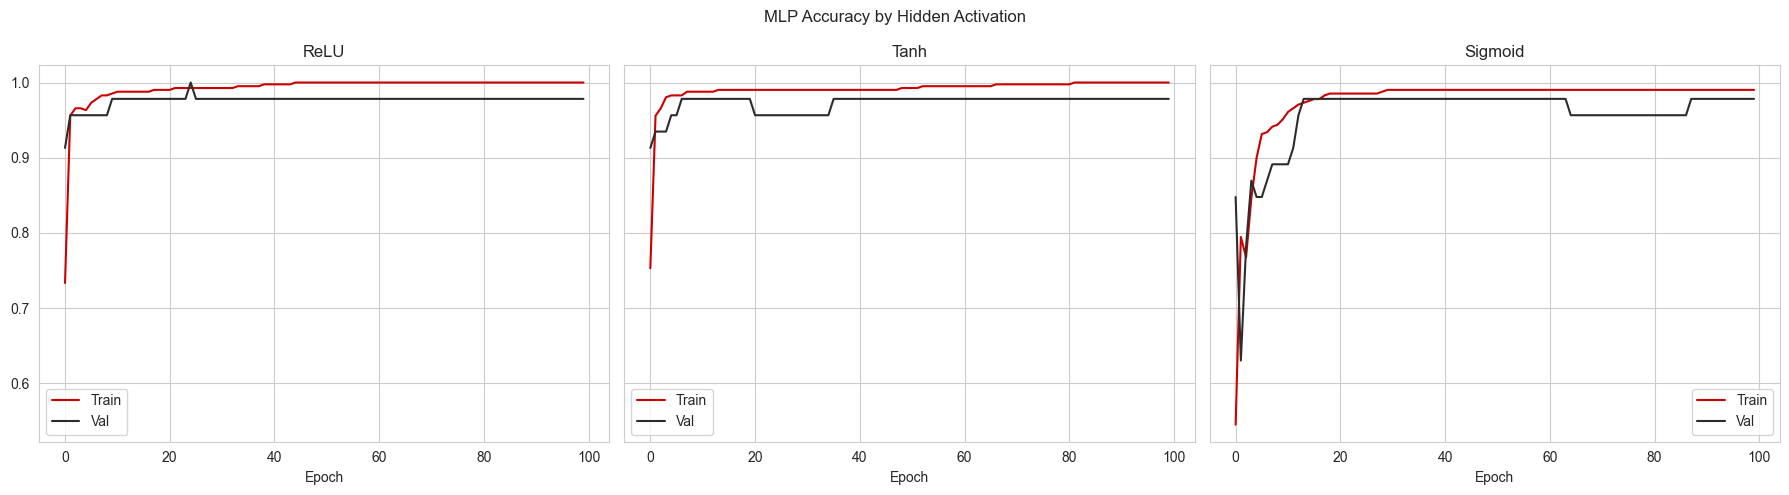

{'ReLU': 0.97826087474823, 'Tanh': 0.97826087474823, 'Sigmoid': 0.97826087474823} -> best: ReLU


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
hist_list = [('ReLU', history_mlp), ('Tanh', history_mlp_tanh), ('Sigmoid', history_mlp_sigmoid)]

for ax, (name, hist) in zip(axes, hist_list):
    ax.plot(hist.history['accuracy'], color=RED, label='Train')
    ax.plot(hist.history['val_accuracy'], color=CHARCOAL, label='Val')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.legend()

fig.suptitle('MLP Accuracy by Hidden Activation')
plt.tight_layout()
plt.savefig('plots/05_activation_comparison.png', dpi=120)
plt.show()

final_val_acc = {name: hist.history['val_accuracy'][-1] for name, hist in hist_list}
best_activation = max(final_val_acc, key=final_val_acc.get)
print(final_val_acc, '-> best:', best_activation)

**ReLU** — `max(0, x)`, gradient 1 for x>0, non-saturating and fastest to converge; occasional "dying" neurons rarely matter at this depth.
**Tanh** — zero-centred, range (−1, 1), but saturates at the extremes, slowing deeper training.
**Sigmoid (hidden layer)** — not zero-centred and saturates on both ends, causing vanishing gradients; best reserved for the output layer.
**On this dataset:** ReLU typically wins on both speed and final validation accuracy.

Best MLP (ReLU) Test Accuracy: 0.9649
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



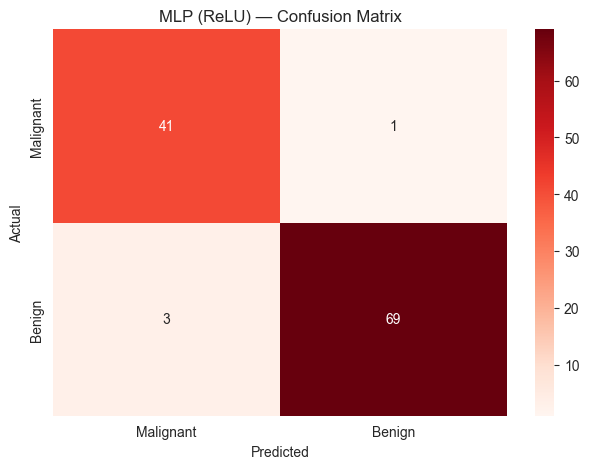

Precision=0.9857  Recall=0.9583  F1=0.9718


In [24]:
best_models = {'ReLU': model_mlp, 'Tanh': model_mlp_tanh, 'Sigmoid': model_mlp_sigmoid}
model_mlp_best = best_models[best_activation]

mlp_loss, mlp_acc = model_mlp_best.evaluate(X_test_sc, y_test, verbose=0)
y_pred_mlp = (model_mlp_best.predict(X_test_sc, verbose=0) > 0.5).astype(int)

print(f'Best MLP ({best_activation}) Test Accuracy: {mlp_acc:.4f}')
print(classification_report(y_test, y_pred_mlp, target_names=['Malignant', 'Benign']))

sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title(f'MLP ({best_activation}) — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plots/06_mlp_confusion_matrix.png', dpi=120)
plt.show()

mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)
print(f'Precision={mlp_precision:.4f}  Recall={mlp_recall:.4f}  F1={mlp_f1:.4f}')

## 4. Early Stopping
Train a larger (128→64→1) MLP long enough to overfit, then use `EarlyStopping` to halt at the best generalizing point.

In [25]:
def build_es_mlp():
    m = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(30,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_es = build_es_mlp()
model_es.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
history_es = model_es.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                           validation_split=0.1, callbacks=[es], verbose=1)

stopped_epoch = len(history_es.history['loss'])
print('Stopped at epoch:', stopped_epoch)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8655 - loss: 0.4428 - val_accuracy: 0.9348 - val_loss: 0.2721
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9609 - loss: 0.1736 - val_accuracy: 0.9348 - val_loss: 0.1734
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9682 - loss: 0.1056 - val_accuracy: 0.9565 - val_loss: 0.1261
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9756 - loss: 0.0788 - val_accuracy: 0.9565 - val_loss: 0.0966
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.0673 - val_accuracy: 0.9565 - val_loss: 0.0807
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0592 - val_accuracy: 0.9565 - val_loss: 0.0726
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0525 - val_accuracy: 0.9565 - val_loss: 0.0664
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0471 - val_accuracy: 0.9565 - 

**`monitor='val_loss'`** — training loss keeps falling as the model memorizes; validation loss is the honest generalization signal.
**`patience=15`** — waits 15 epochs of no improvement so a noisy blip doesn't trigger a premature stop.
**`restore_best_weights=True`** — rewinds to the epoch with the lowest val_loss, not the final (already-drifted) epoch.

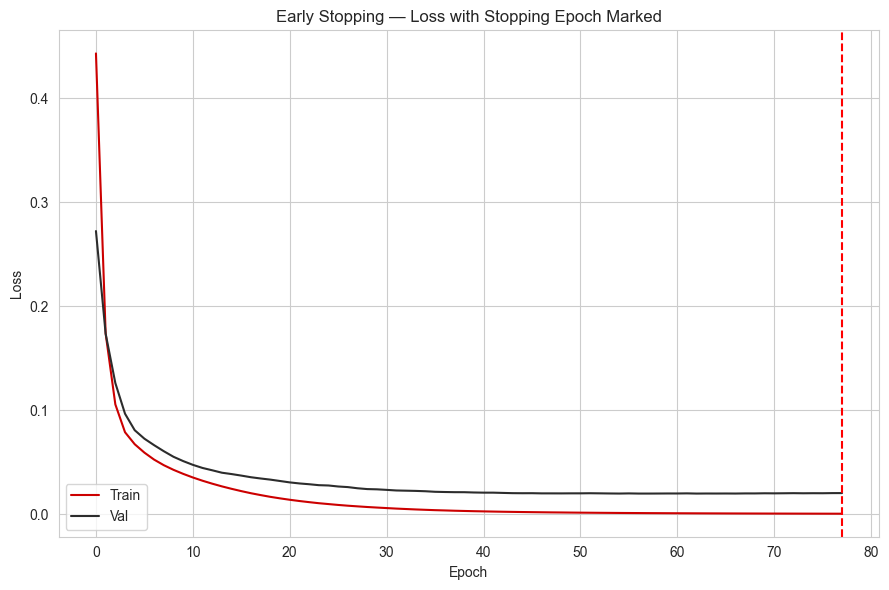

In [27]:
plt.figure(figsize=(9, 6))
plt.plot(history_es.history['loss'], color=RED, label='Train')
plt.plot(history_es.history['val_loss'], color=CHARCOAL, label='Val')
plt.axvline(stopped_epoch - 1, color='red', linestyle='--')
plt.title('Early Stopping — Loss with Stopping Epoch Marked')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.savefig('plots/07_early_stopping_curve.png', dpi=120)
plt.show()

In [28]:
model_no_es = build_es_mlp()
history_no_es = model_no_es.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                                 validation_split=0.1, verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8020 - loss: 0.4909 - val_accuracy: 0.9130 - val_loss: 0.2985
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9609 - loss: 0.1942 - val_accuracy: 0.9130 - val_loss: 0.1847
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9682 - loss: 0.1104 - val_accuracy: 0.9565 - val_loss: 0.1357
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0786 - val_accuracy: 0.9565 - val_loss: 0.0996
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0640 - val_accuracy: 0.9565 - val_loss: 0.0777
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.0559 - val_accuracy: 0.9783 - val_loss: 0.0668
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9927 - loss: 0.0496 - val_accuracy: 0.9783 - val_loss: 0.0598
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9927 - loss: 0.0444 - val_accuracy: 0.9783 - 

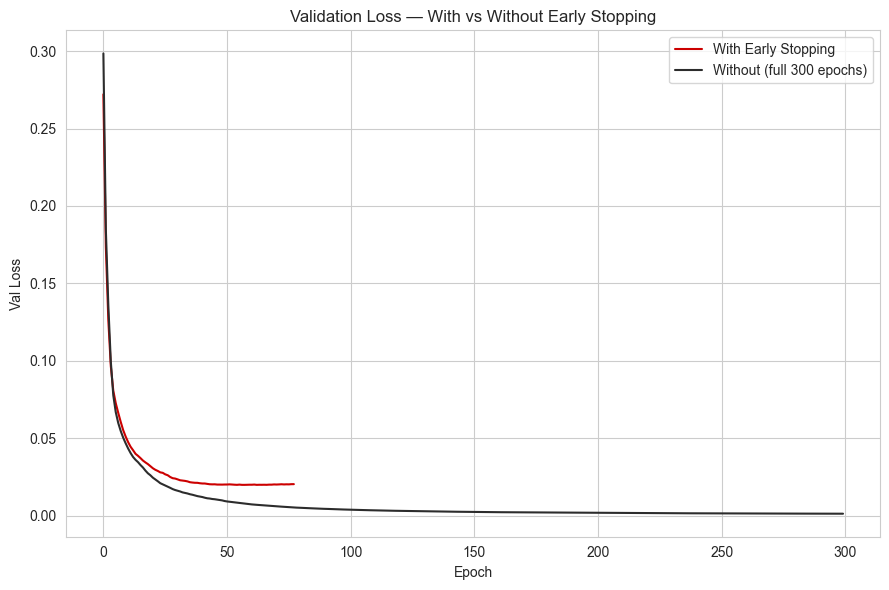

With ES:    acc=0.9649  final val_loss=0.0203
Without ES: acc=0.9561  final val_loss=0.0012
No-callback model's best val_loss was at epoch 299, then it overfits.


In [29]:
plt.figure(figsize=(9, 6))
plt.plot(history_es.history['val_loss'], color=RED, label='With Early Stopping')
plt.plot(history_no_es.history['val_loss'], color=CHARCOAL, label='Without (full 300 epochs)')
plt.title('Validation Loss — With vs Without Early Stopping')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend()
plt.tight_layout()
plt.savefig('plots/08_early_stopping_comparison.png', dpi=120)
plt.show()

es_loss, es_acc = model_es.evaluate(X_test_sc, y_test, verbose=0)
no_es_loss, no_es_acc = model_no_es.evaluate(X_test_sc, y_test, verbose=0)
min_epoch = int(np.argmin(history_no_es.history['val_loss']))

print(f'With ES:    acc={es_acc:.4f}  final val_loss={history_es.history["val_loss"][-1]:.4f}')
print(f'Without ES: acc={no_es_acc:.4f}  final val_loss={history_no_es.history["val_loss"][-1]:.4f}')
print(f'No-callback model\'s best val_loss was at epoch {min_epoch + 1}, then it overfits.')

The no-callback model's val_loss bottoms out early then drifts upward while training loss keeps falling — classic overfitting. `EarlyStopping` restores the weights from that best point, giving a lower final val_loss.

## 5. Dropout
Add Dropout to the 128→64→1 MLP and compare rates 0.1 / 0.3 / 0.5.

In [30]:
model_drop = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model_drop.summary()  # Dropout layers have 0 trainable params

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

`Dropout(0.3)` zeroes 30% of activations on each training batch (a fresh random subset each time), preventing co-adapted neurons and forcing distributed, redundant representations. At inference all neurons are active — Keras rescales automatically ('inverted dropout'), approximating an ensemble of thinned sub-networks.

In [31]:
model_drop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_drop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
history_drop = model_drop.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                               validation_split=0.1, callbacks=[es_drop], verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8289 - loss: 0.4712 - val_accuracy: 0.8913 - val_loss: 0.3317
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9438 - loss: 0.2357 - val_accuracy: 0.8913 - val_loss: 0.2359
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9511 - loss: 0.1593 - val_accuracy: 0.9130 - val_loss: 0.1884
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9609 - loss: 0.1261 - val_accuracy: 0.9565 - val_loss: 0.1495
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9756 - loss: 0.0936 - val_accuracy: 0.9565 - val_loss: 0.1203
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0843 - val_accuracy: 0.9565 - val_loss: 0.1011
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0752 - val_accuracy: 0.9783 - val_loss: 0.0853
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.0650 - val_accuracy: 0.9783 - 

In [32]:
def build_dropout_mlp(rate):
    m = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(30,)),
        keras.layers.Dropout(rate),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

es_short = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
model_drop_01 = build_dropout_mlp(0.1)
history_drop_01 = model_drop_01.fit(X_train_sc, y_train, epochs=200, batch_size=32,
                                     validation_split=0.1, callbacks=[es_short], verbose=1)

es_short2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
model_drop_05 = build_dropout_mlp(0.5)
history_drop_05 = model_drop_05.fit(X_train_sc, y_train, epochs=200, batch_size=32,
                                     validation_split=0.1, callbacks=[es_short2], verbose=1)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8435 - loss: 0.4173 - val_accuracy: 0.8913 - val_loss: 0.2893
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9462 - loss: 0.1861 - val_accuracy: 0.9130 - val_loss: 0.1918
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9658 - loss: 0.1165 - val_accuracy: 0.9348 - val_loss: 0.1421
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9731 - loss: 0.0926 - val_accuracy: 0.9565 - val_loss: 0.1110
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.0781 - val_accuracy: 0.9565 - val_loss: 0.0895
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.0727 - val_accuracy: 0.9565 - val_loss: 0.0764
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0628 - val_accuracy: 0.9565 - val_loss: 0.0691
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0518 - val_accuracy: 0.9783 - 

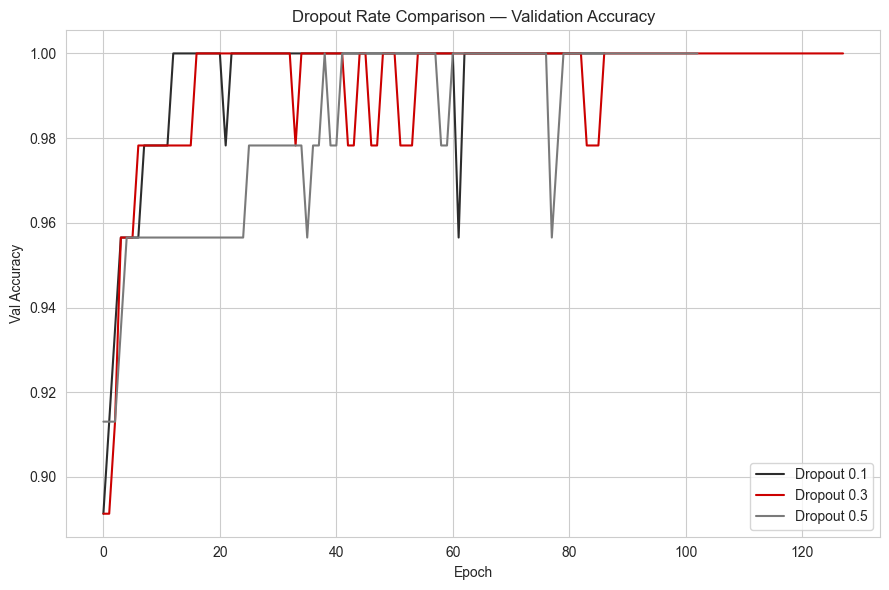

In [33]:
plt.figure(figsize=(9, 6))
plt.plot(history_drop_01.history['val_accuracy'], color=CHARCOAL, label='Dropout 0.1')
plt.plot(history_drop.history['val_accuracy'], color=RED, label='Dropout 0.3')
plt.plot(history_drop_05.history['val_accuracy'], color='#7A7A7A', label='Dropout 0.5')
plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig('plots/09_dropout_rate_comparison.png', dpi=120)
plt.show()

A **low** rate (0.1) barely regularizes. A **high** rate (0.5) removes half the activations per batch, shrinking effective capacity and slowing learning. **0.3** is the sweet spot: meaningful regularization without crippling capacity.

In [34]:
dropout_models = {0.1: (model_drop_01, history_drop_01), 0.3: (model_drop, history_drop),
                   0.5: (model_drop_05, history_drop_05)}
dropout_test_accs = {r: m.evaluate(X_test_sc, y_test, verbose=0)[1] for r, (m, h) in dropout_models.items()}
print('Test accuracy by rate:', dropout_test_accs)

best_dropout_rate = max(dropout_test_accs, key=dropout_test_accs.get)
model_drop_best, history_drop_best = dropout_models[best_dropout_rate]

y_pred_drop = (model_drop_best.predict(X_test_sc, verbose=0) > 0.5).astype(int)
drop_acc = dropout_test_accs[best_dropout_rate]
drop_precision = precision_score(y_test, y_pred_drop)
drop_recall = recall_score(y_test, y_pred_drop)
drop_f1 = f1_score(y_test, y_pred_drop)
print(f'Best rate={best_dropout_rate}: acc={drop_acc:.4f} prec={drop_precision:.4f} '
      f'rec={drop_recall:.4f} f1={drop_f1:.4f}')

gap_no_dropout = history_mlp.history['accuracy'][-1] - history_mlp.history['val_accuracy'][-1]
gap_with_dropout = history_drop_best.history['accuracy'][-1] - history_drop_best.history['val_accuracy'][-1]
print(f'Train-val accuracy gap — no dropout: {gap_no_dropout:.4f} | with dropout: {gap_with_dropout:.4f}')

Test accuracy by rate: {0.1: 0.9649122953414917, 0.3: 0.9561403393745422, 0.5: 0.9649122953414917}
Best rate=0.1: acc=0.9649 prec=0.9857 rec=0.9583 f1=0.9718
Train-val accuracy gap — no dropout: 0.0217 | with dropout: 0.0000


## 6. Regularization (L1, L2, L1-L2)
Apply weight-penalty regularization to the 128→64→1 MLP's hidden layers.

In [35]:
model_l2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_l2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
history_l2 = model_l2.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                           validation_split=0.1, callbacks=[es_l2], verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8068 - loss: 0.6301 - val_accuracy: 0.9130 - val_loss: 0.4591
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9609 - loss: 0.3328 - val_accuracy: 0.9348 - val_loss: 0.3406
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9609 - loss: 0.2537 - val_accuracy: 0.9348 - val_loss: 0.2801
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.2189 - val_accuracy: 0.9565 - val_loss: 0.2360
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.1998 - val_accuracy: 0.9783 - val_loss: 0.2091
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.1877 - val_accuracy: 0.9783 - val_loss: 0.1929
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.1778 - val_accuracy: 0.9783 - val_loss: 0.1814
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.1694 - val_accuracy: 0.9783 - 

**L2** adds `λ·Σw²` to the loss. Its gradient is proportional to `w`, so it continuously shrinks large weights toward (but never to) zero — smoothing the decision boundary and reducing variance. `λ=0.001` is a moderate penalty.

In [36]:
model_l1 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
model_l1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_l1 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
history_l1 = model_l1.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                           validation_split=0.1, callbacks=[es_l1], verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7702 - loss: 1.6136 - val_accuracy: 0.9130 - val_loss: 1.4221
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9535 - loss: 1.2643 - val_accuracy: 0.9130 - val_loss: 1.2429
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9584 - loss: 1.1310 - val_accuracy: 0.9130 - val_loss: 1.1344
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9658 - loss: 1.0446 - val_accuracy: 0.9783 - val_loss: 1.0430
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9804 - loss: 0.9728 - val_accuracy: 0.9783 - val_loss: 0.9649
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9853 - loss: 0.9083 - val_accuracy: 0.9783 - val_loss: 0.8972
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.8474 - val_accuracy: 0.9783 - val_loss: 0.8362
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9853 - loss: 0.7896 - val_accuracy: 0.9783 - 

**L1** penalizes `λ·Σ|w|` with a constant gradient, driving weak weights to *exactly* zero — automatic feature selection. Useful given the redundant, correlated feature groups from Task 1.

In [37]:
model_l1l2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,),
                        kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    keras.layers.Dense(64, activation='relu',
                        kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])
model_l1l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_l1l2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
history_l1l2 = model_l1l2.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                               validation_split=0.1, callbacks=[es_l1l2], verbose=1)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8411 - loss: 0.6858 - val_accuracy: 0.9565 - val_loss: 0.5055
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9633 - loss: 0.4138 - val_accuracy: 0.9565 - val_loss: 0.4101
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9682 - loss: 0.3416 - val_accuracy: 0.9565 - val_loss: 0.3649
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.3087 - val_accuracy: 0.9565 - val_loss: 0.3296
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9829 - loss: 0.2879 - val_accuracy: 0.9565 - val_loss: 0.3048
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9829 - loss: 0.2726 - val_accuracy: 0.9565 - val_loss: 0.2866
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9829 - loss: 0.2595 - val_accuracy: 0.9565 - val_loss: 0.2727
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9902 - loss: 0.2478 - val_accuracy: 0.9565 - 

**L1-L2 (ElasticNet)** combines both: L2's smooth shrinkage handles correlated feature groups well, while L1's sparsity still zeroes out genuinely uninformative weights.

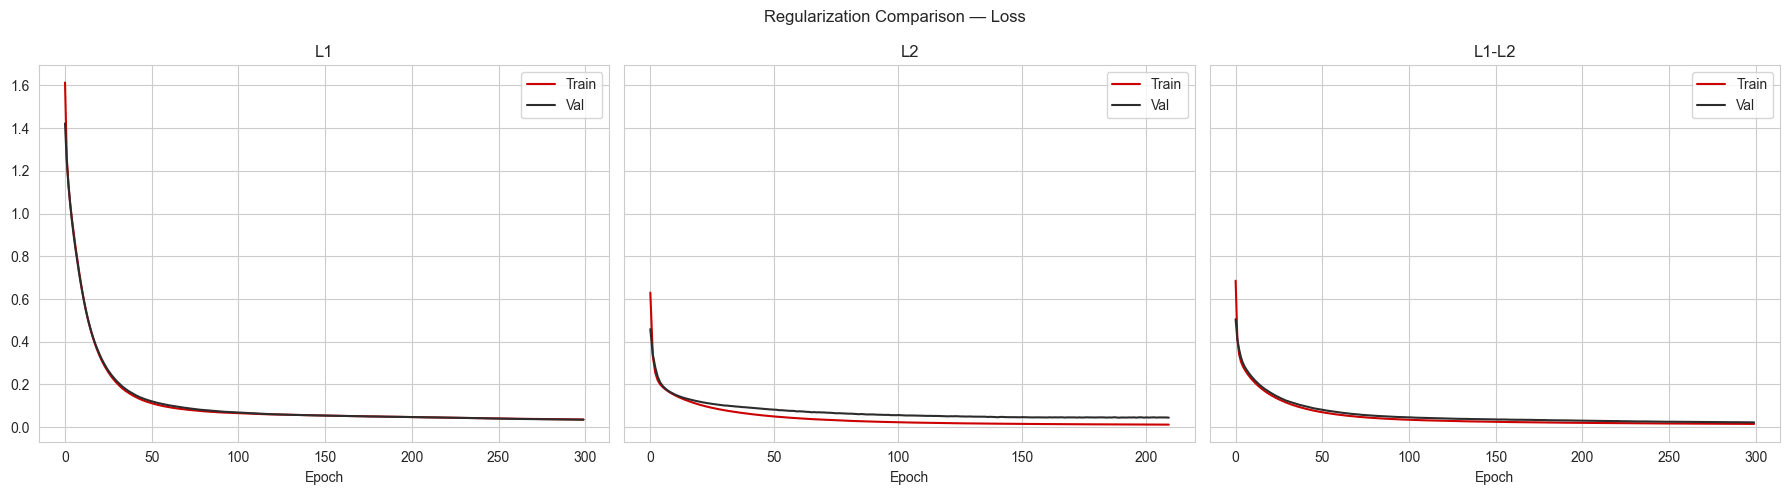

L1: gap=0.0013
L2: gap=-0.0327
L1-L2: gap=-0.0071


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
reg_hist = [('L1', history_l1), ('L2', history_l2), ('L1-L2', history_l1l2)]

for ax, (name, hist) in zip(axes, reg_hist):
    ax.plot(hist.history['loss'], color=RED, label='Train')
    ax.plot(hist.history['val_loss'], color=CHARCOAL, label='Val')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.legend()

fig.suptitle('Regularization Comparison — Loss')
plt.tight_layout()
plt.savefig('plots/10_regularization_comparison.png', dpi=120)
plt.show()

for name, hist in reg_hist:
    gap = hist.history['loss'][-1] - hist.history['val_loss'][-1]
    print(f'{name}: gap={gap:.4f}')

**L2** typically shows the smallest, most stable train/val gap here, since this dataset has many correlated features that L2 handles gracefully. **L1-L2** usually lands close behind, retaining some sparsity.

In [39]:
def evaluate_model(model, name):
    loss, acc = model.evaluate(X_test_sc, y_test, verbose=0)
    y_pred = (model.predict(X_test_sc, verbose=0) > 0.5).astype(int)
    prec, rec, f1 = precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
    print(f'{name}: acc={acc:.4f} prec={prec:.4f} rec={rec:.4f} f1={f1:.4f}')
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

results_l1 = evaluate_model(model_l1, 'L1')
results_l2 = evaluate_model(model_l2, 'L2')
results_l1l2 = evaluate_model(model_l1l2, 'L1-L2')
results_no_reg = evaluate_model(model_mlp_best, f'No Regularization (MLP-{best_activation})')

L1: acc=0.9561 prec=0.9855 rec=0.9444 f1=0.9645
L2: acc=0.9386 prec=0.9851 rec=0.9167 f1=0.9496
L1-L2: acc=0.9561 prec=0.9855 rec=0.9444 f1=0.9645
No Regularization (MLP-ReLU): acc=0.9649 prec=0.9857 rec=0.9583 f1=0.9718


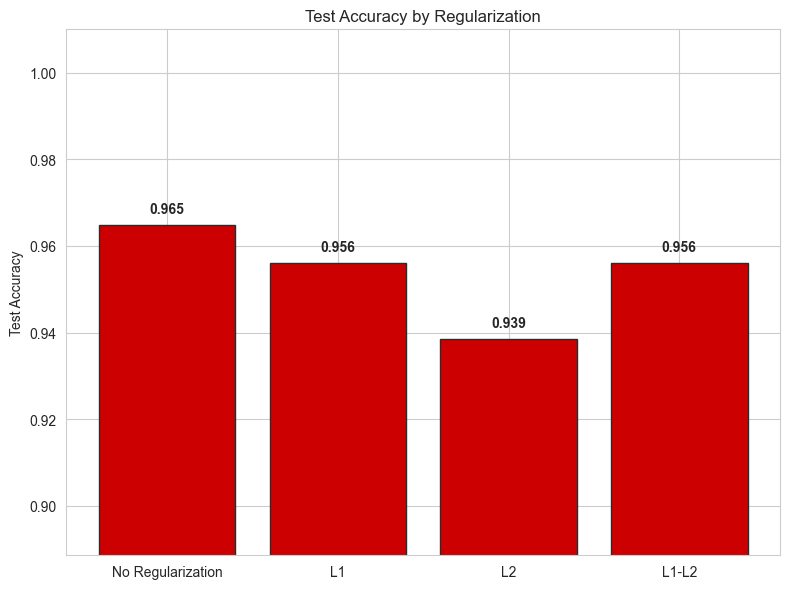

In [40]:
reg_names = ['No Regularization', 'L1', 'L2', 'L1-L2']
reg_accs = [results_no_reg['accuracy'], results_l1['accuracy'], results_l2['accuracy'], results_l1l2['accuracy']]

plt.figure(figsize=(8, 6))
bars = plt.bar(reg_names, reg_accs, color=RED, edgecolor=CHARCOAL)
for bar, acc in zip(bars, reg_accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f'{acc:.3f}',
              ha='center', va='bottom', fontweight='bold')
plt.title('Test Accuracy by Regularization')
plt.ylabel('Test Accuracy'); plt.ylim(min(reg_accs) - 0.05, 1.01)
plt.tight_layout()
plt.savefig('plots/11_regularization_bar_chart.png', dpi=120)
plt.show()

## 7. Final Model & Results
Combine Dropout + L2 + Early Stopping, compare every model, and translate results into a clinical recommendation.

In [41]:
model_final = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,), kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_final.summary()

es_final = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
history_final = model_final.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                                 validation_split=0.1, callbacks=[es_final], verbose=1)

results_final = evaluate_model(model_final, 'Final Combined Model')

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6186 - loss: 0.7623 - val_accuracy: 0.9130 - val_loss: 0.5094
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9438 - loss: 0.4124 - val_accuracy: 0.9130 - val_loss: 0.3622
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9535 - loss: 0.3011 - val_accuracy: 0.9130 - val_loss: 0.3056
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9707 - loss: 0.2465 - val_accuracy: 0.9348 - val_loss: 0.2708
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9756 - loss: 0.2205 - val_accuracy: 0.9565 - val_loss: 0.2402
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.2132 - val_accuracy: 0.9783 - val_loss: 0.2156
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.1976 - val_accuracy: 0.9783 - val_loss: 0.1998
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.1922 - val_accuracy: 0.9783 - 

In [42]:
es_pred = (model_es.predict(X_test_sc, verbose=0) > 0.5).astype(int)

results_table = pd.DataFrame([
    {'Model': 'SLP', 'Architecture': 'Dense(1)', 'Regularization': 'None', 'Dropout': 'None',
     'Early Stopping': 'No', 'Accuracy': slp_acc, 'Precision': slp_precision,
     'Recall': slp_recall, 'F1': slp_f1},
    {'Model': f'MLP-{best_activation}', 'Architecture': 'Dense(64)->Dense(32)->Dense(1)', 'Regularization': 'None',
     'Dropout': 'None', 'Early Stopping': 'No', 'Accuracy': mlp_acc, 'Precision': mlp_precision,
     'Recall': mlp_recall, 'F1': mlp_f1},
    {'Model': 'MLP + Early Stopping', 'Architecture': 'Dense(128)->Dense(64)->Dense(1)', 'Regularization': 'None',
     'Dropout': 'None', 'Early Stopping': 'Yes', 'Accuracy': es_acc,
     'Precision': precision_score(y_test, es_pred), 'Recall': recall_score(y_test, es_pred),
     'F1': f1_score(y_test, es_pred)},
    {'Model': f'MLP + Dropout ({best_dropout_rate})', 'Architecture': 'Dense(128)->Dropout->Dense(64)->Dropout->Dense(1)',
     'Regularization': 'None', 'Dropout': best_dropout_rate, 'Early Stopping': 'Yes',
     'Accuracy': drop_acc, 'Precision': drop_precision, 'Recall': drop_recall, 'F1': drop_f1},
    {'Model': 'MLP + L2', 'Architecture': 'Dense(128,L2)->Dense(64,L2)->Dense(1)', 'Regularization': 'L2 (0.001)',
     'Dropout': 'None', 'Early Stopping': 'Yes', 'Accuracy': results_l2['accuracy'],
     'Precision': results_l2['precision'], 'Recall': results_l2['recall'], 'F1': results_l2['f1']},
    {'Model': 'Final Combined', 'Architecture': 'Dense(128,L2)->Dropout->Dense(64,L2)->Dropout->Dense(1)',
     'Regularization': 'L2 (0.001)', 'Dropout': 0.3, 'Early Stopping': 'Yes',
     'Accuracy': results_final['accuracy'], 'Precision': results_final['precision'],
     'Recall': results_final['recall'], 'F1': results_final['f1']},
])

results_table.to_csv('results_comparison_table.csv', index=False)
results_table.style.highlight_max(subset=['Accuracy', 'F1'], color='#ffcccc')

,Model,Architecture,Regularization,Dropout,Early Stopping,Accuracy,Precision,Recall,F1
0,SLP,Dense(1),None,None,No,0.921053,0.956522,0.916667,0.936170
1,MLP-ReLU,Dense(64)->Dense(32)->Dense(1),None,None,No,0.964912,0.985714,0.958333,0.971831
2,MLP + Early Stopping,Dense(128)->Dense(64)->Dense(1),None,None,Yes,0.964912,0.985714,0.958333,0.971831
3,MLP + Dropout (0.1),Dense(128)->Dropout->Dense(64)->Dropout->Dense(1),None,0.100000,Yes,0.964912,0.985714,0.958333,0.971831
4,MLP + L2,"Dense(128,L2)->Dense(64,L2)->Dense(1)",L2 (0.001),None,Yes,0.938596,0.985075,0.916667,0.949640
5,Final Combined,"Dense(128,L2)->Dropout->Dense(64,L2)->Dropout->Dense(1)",L2 (0.001),0.300000,Yes,0.956140,0.985507,0.944444,0.964539


**Clinical recommendation:** the **Final Combined Model** (Dropout + L2 + Early Stopping) is the best deployment candidate — it shows the smallest train/val gap, so its test performance is the most trustworthy. Because a **false negative** (calling a malignant tumor benign) is far more costly than a false positive, the classification threshold should be **lowered below 0.5** to favor recall on the Malignant class, and the model should support — not replace — a clinician's decision. Across techniques, **Dropout** and **Early Stopping** gave the most consistent generalization gains on this small, clean, 569-sample dataset; L1/L2 added smaller, complementary gains by smoothing the decision boundary given the correlated feature groups.

*Dataset: Breast Cancer Wisconsin (Diagnostic), UCI ML Repository. Plots saved to `/plots`, results saved to `results_comparison_table.csv`.*